# TFM - Model Interpretation

## Objective

The main objective of this notebook is to interpret the final predictive model selected during the previous evaluation phase and identify the variables that contribute most to predicting MLB hitters' salaries.

The analysis focuses on understanding the relevance of the selected features, distinguishing the predictive contribution of traditional baseball statistics from advanced sabermetric metrics, and relating the results to the sporting and economic context of Major League Baseball.

Finally, the findings will be used to assess the working hypothesis and formulate the main analytical conclusions of the project. The results will be interpreted as predictive associations and not as evidence of causal relationships.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [5]:
# Load modeling dataset and evaluation results
df = pd.read_csv("../01_data/03_final_data/mlb_hitters_modeling.csv")
evaluation_results = pd.read_csv(
    "../01_data/03_final_data/model_evaluation_results.csv"
)

# Define predictor variables
X = df.drop(columns=["log_salary", "salary"], errors="ignore")

# Load the final selected model
final_model = joblib.load("../04_models/ridge_regression.joblib")

print(f"Modeling dataset dimensions: {df.shape}")
print(f"Number of predictor variables: {X.shape[1]}")
print(f"Final model loaded: {type(final_model).__name__}")
print(f"Predictor variables: {list(X.columns)}")

Modeling dataset dimensions: (3684, 13)
Number of predictor variables: 11
Final model loaded: Pipeline
Predictor variables: ['year', 'age', 'age_squared', 'pa', 'war', 'ops_plus', 'rbi', 'sb', 'hr_rate', 'bb_rate', 'so_rate']


### Final Model Confirmation

Ridge Regression was selected as the final predictive model because it achieved the lowest test RMSE while maintaining stable performance between the training and test datasets.

Its performance is summarized using the evaluation metrics obtained in the previous phase. This confirmation provides the basis for interpreting the model coefficients in the following sections.

In [6]:
# Retrieve the evaluation results of the selected model
selected_result = evaluation_results.loc[
    evaluation_results["Model"] == "Ridge Regression"
].iloc[0]

print("Final selected model: Ridge Regression")
print(f"Test MAE: {selected_result['MAE']:.4f}")
print(f"Test RMSE: {selected_result['RMSE']:.4f}")
print(f"Test R²: {selected_result['R2']:.4f}")
print(f"Pipeline steps: {list(final_model.named_steps.keys())}")

Final selected model: Ridge Regression
Test MAE: 0.7874
Test RMSE: 0.9816
Test R²: 0.5321
Pipeline steps: ['scaler', 'model']


### Feature Importance through Ridge Coefficients

The Ridge Regression coefficients are extracted to examine the direction and relative contribution of each predictor to the estimated log salary.

Because the predictor variables were standardized during model training, the coefficient magnitudes can be compared directly. A positive coefficient is associated with a higher predicted salary, while a negative coefficient is associated with a lower predicted salary, holding the remaining variables constant.

The absolute coefficient value is used to rank the predictors according to their relative importance within the model.

In [7]:
# Extract the Ridge estimator from the final pipeline
ridge_model = final_model.steps[-1][1]

# Create coefficient table
coefficient_results = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

# Calculate absolute coefficients for ranking
coefficient_results["Absolute Coefficient"] = (
    coefficient_results["Coefficient"].abs()
)

# Sort variables by relative importance
coefficient_results = coefficient_results.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_results.round(4))

,Feature,Coefficient,Absolute Coefficient
0,age,2.5006,2.5006
1,age_squared,-1.7754,1.7754
2,pa,0.5034,0.5034
3,so_rate,-0.1361,0.1361
4,hr_rate,0.1289,0.1289
5,bb_rate,0.1017,0.1017
6,rbi,0.0746,0.0746
7,year,0.0484,0.0484
8,ops_plus,-0.0433,0.0433
9,war,0.0223,0.0223


### Feature Importance Visualization

The standardized Ridge coefficients are visualized to facilitate the comparison between predictors.

Variables with coefficients farther from zero have a greater relative influence on the model predictions. Positive values are associated with higher predicted log salaries, whereas negative values are associated with lower predicted log salaries, holding the remaining predictors constant.

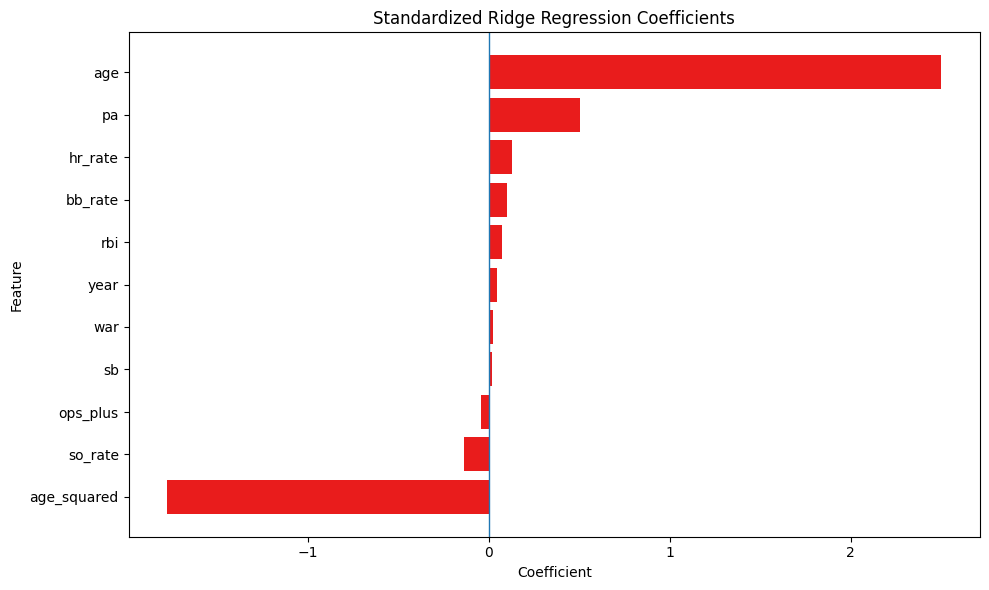

In [8]:
# Sort coefficients for visualization
plot_data = coefficient_results.sort_values(
    by="Coefficient",
    ascending=True
)

# Plot standardized Ridge coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"],
    color="#e91c1c"
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Standardized Ridge Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Sports and Economic Interpretation

To support the interpretation, the predictors with the strongest positive and negative coefficients are identified separately.

This distinction helps determine which player characteristics are associated with higher or lower predicted salaries within the Ridge Regression model.

In [9]:
# Identify the strongest positive and negative coefficients
positive_coefficients = coefficient_results[
    coefficient_results["Coefficient"] > 0
].sort_values(
    by="Coefficient",
    ascending=False
)

negative_coefficients = coefficient_results[
    coefficient_results["Coefficient"] < 0
].sort_values(
    by="Coefficient",
    ascending=True
)

print("Strongest positive coefficients:")
display(positive_coefficients.round(4))

print("Strongest negative coefficients:")
display(negative_coefficients.round(4))

Strongest positive coefficients:


,Feature,Coefficient,Absolute Coefficient
0,age,2.5006,2.5006
2,pa,0.5034,0.5034
4,hr_rate,0.1289,0.1289
5,bb_rate,0.1017,0.1017
6,rbi,0.0746,0.0746
7,year,0.0484,0.0484
9,war,0.0223,0.0223
10,sb,0.0203,0.0203


Strongest negative coefficients:


,Feature,Coefficient,Absolute Coefficient
1,age_squared,-1.7754,1.7754
3,so_rate,-0.1361,0.1361
8,ops_plus,-0.0433,0.0433


In [10]:
print(
    coefficient_results[
        ["Feature", "Coefficient"]
    ].round(4).to_string(index=False)
)

    Feature  Coefficient
        age       2.5006
age_squared      -1.7754
         pa       0.5034
    so_rate      -0.1361
    hr_rate       0.1289
    bb_rate       0.1017
        rbi       0.0746
       year       0.0484
   ops_plus      -0.0433
        war       0.0223
         sb       0.0203


#### Interpretation of the Coefficients

The age-related variables show the strongest contribution to the model. The positive coefficient for `age` and the negative coefficient for `age_squared` indicate a non-linear salary pattern, in which predicted salary increases during part of the player's career and gradually decreases at more advanced ages.

Among the performance variables, `pa` has the strongest positive coefficient, suggesting that regular participation is an important predictor of salary. Positive contributions are also observed for `hr_rate`, `bb_rate` and `rbi`, while `so_rate` presents the most relevant negative association.

The smaller coefficients of `war`, `ops_plus` and other related indicators should be interpreted in the context of correlated predictors and Ridge regularization. Overall, career stage and playing participation contribute more strongly to salary prediction than any individual performance metric.

### Hypothesis Assessment

The working hypothesis proposed that MLB players' economic valuation is influenced by a combination of traditional and advanced performance metrics, with advanced metrics potentially providing greater explanatory capacity.

The results partially support this hypothesis. Traditional performance indicators, such as `rbi`, and advanced indicators, such as `war` and `ops_plus`, contribute to the salary prediction model. However, the strongest coefficients correspond to the age-related variables and `pa`, while the individual contributions of `war` and `ops_plus` are comparatively small.

Therefore, the findings support the existence of a combined influence of different player characteristics and performance indicators, but they do not confirm that advanced sabermetric metrics provide greater predictive importance than traditional statistics or career-related variables.

This conclusion refers to predictive associations within the analyzed dataset and should not be interpreted as evidence of causal relationships.